In [1]:
# Plot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# sklearn: test
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    f1_score, 
    roc_curve, 
    auc, 
    balanced_accuracy_score
)
# Model
import torch
# sklearn: pipeline
from sklearn.pipeline import Pipeline
# Data
import pandas as pd
# Import
import pickle



# Local libraries
from utils.torch_lib.TabularTransformer import TabularTransformer, TransactionDataset, TabularTransformerWrapper
from utils.skl_lib.LibPreTabTransformer import MaskedPCA, shift_plus_one

In [2]:
CSV_TEST_PATH = '../../data_ieee/transactions_test.feather'
PKL_PATH = '../../models/preprocessing_config.pkl'
TARGET_COL = 'isFraud'

In [3]:
df = pd.read_feather(CSV_TEST_PATH)

y = torch.tensor(df[TARGET_COL].values, dtype=torch.long)
X = df.drop(columns=[TARGET_COL])

In [4]:
ckpt = torch.load('../../models/TabularTransformer_checkpoint.pth', weights_only=False)


model = TabularTransformer(**ckpt['config']) 
model.load_state_dict(ckpt['model_state_dict'])


wrapped_model = TabularTransformerWrapper(model, batch_size=128)

with open(PKL_PATH, 'rb') as f:
    config = pickle.load(f)

wrapped_model.fitted_ = True
pipeline = Pipeline([
    ('scaler', config['preprocessor']),
    ('classifier', wrapped_model)
])
pipeline.fitted_ = True

In [5]:
def evaluar_modelo(y_test, y_pred, y_proba):

    print("=== REPORTE DE CLASIFICACIÓN ===")
    print(classification_report(y_test, y_pred))
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    b_acc = balanced_accuracy_score(y_test, y_pred) 
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"F1 Weighted: {f1_w:.4f}")
    print(f"Balanced Accuracy: {b_acc:.4f}")
    print("-" * 30)


    fig, ax = plt.subplots(1, 2, figsize=(15, 5))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Matriz de Confusión (Cantidades)')
    ax[0].set_xlabel('Predicción')
    ax[0].set_ylabel('Real')


    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax[1])
    ax[1].set_title('Matriz de Confusión (Probabilidades)')
    ax[1].set_xlabel('Predicción')
    ax[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.show()


    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()



In [6]:
y_test = y
X_test = X
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1] 

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99    113975
           1       0.89      0.27      0.41      4133

    accuracy                           0.97    118108
   macro avg       0.93      0.63      0.70    118108
weighted avg       0.97      0.97      0.97    118108

Accuracy: 0.9732
F1: 0.4090
F1 Weighted: 0.9661
Balanced Accuracy: 0.6321
------------------------------


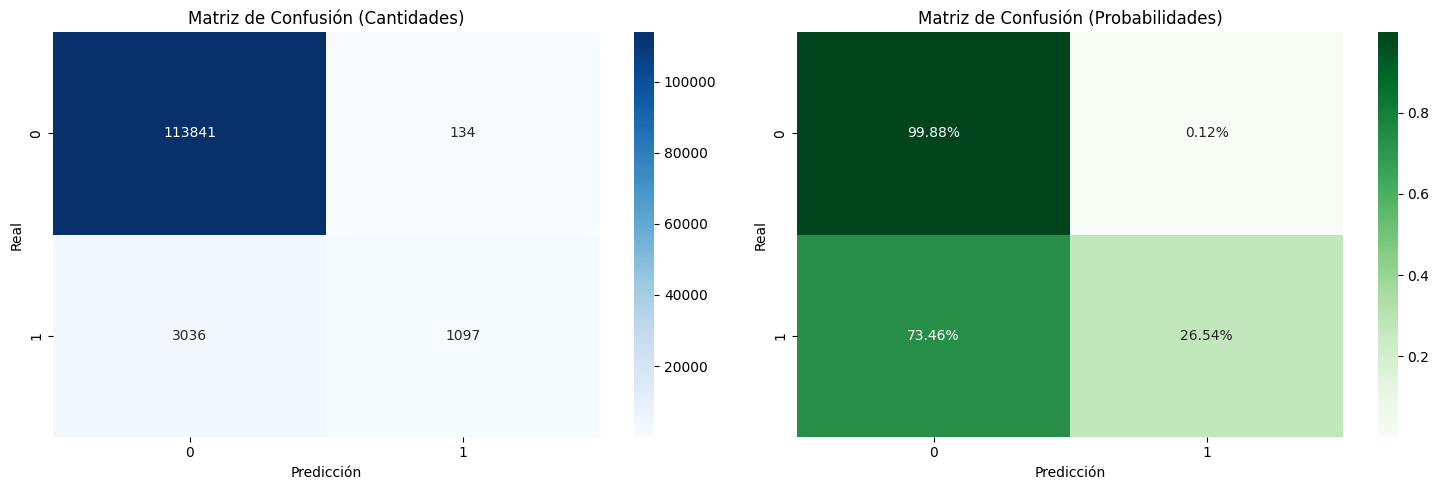

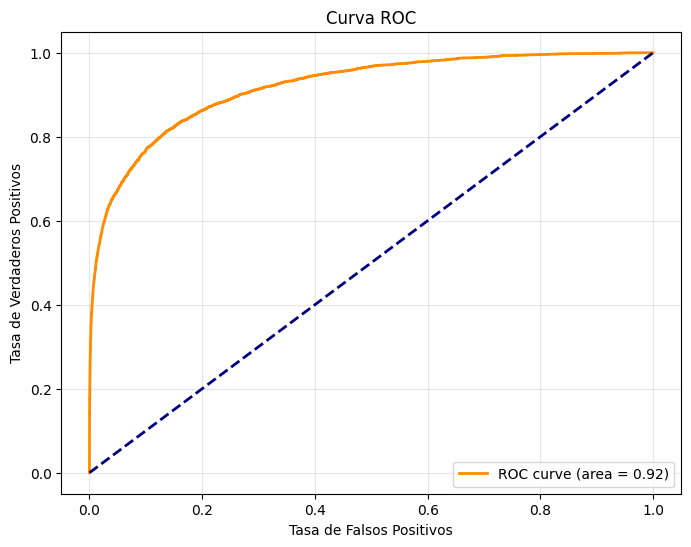

In [7]:

evaluar_modelo(y_test, y_pred, y_proba)

In [8]:

from ipywidgets import interact, FloatSlider

def test_interactivo(y_test, y_proba):
    # Aseguramos que los datos sean vectores planos (evita el error de dimensiones)
    y_test = np.array(y_test).ravel()
    y_proba = np.array(y_proba).ravel()
    
    @interact(threshold=FloatSlider(min=0.01, max=0.99, step=0.05, value=0.5))
    def actualizar_graficas(threshold):
        
        y_pred = (y_proba >= threshold).astype(int)
        
        # --- CÁLCULO DE MÉTRICAS ---
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        b_acc = balanced_accuracy_score(y_test, y_pred)
        
        print(f"=== TEST CON THRESHOLD: {threshold:.2f} ===")
        print(f"Accuracy: {acc:.4f} | F1 Weighted: {f1_w:.4f} | F1: {f1:.4f} | Balanced Acc: {b_acc:.4f}")
        print("-" * 65)

        # --- FIGURA PRINCIPAL ---
        fig, ax = plt.subplots(1, 3, figsize=(20, 5))

        # A. Matriz de Cantidades
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
        ax[0].set_title('Cantidades')
        ax[0].set_xlabel('Predicción')
        ax[0].set_ylabel('Real')

        # B. Matriz de Probabilidades (Normalizada)
        cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax[1])
        ax[1].set_title('Precisión por Clase (%)')
        ax[1].set_xlabel('Predicción')

        # C. HISTOGRAMA DE ERROR Y ACIERTO
        aciertos = y_proba[y_test == y_pred]
        errores = y_proba[y_test != y_pred]
        

        ax[2].hist(aciertos, bins=30, alpha=0.4, label='Aciertos', color='gray')
        
        if len(errores) > 0:
            ax[2].hist(errores, bins=30, alpha=0.7, label='Errores (Misclass)', color='red')
            
        ax[2].axvline(threshold, color='black', linestyle='--', lw=2, label=f'Umbral: {threshold}')
        ax[2].set_title('Distribución de Probabilidades')
        ax[2].set_xlabel('Probabilidad de ser Clase 1 (Fraude)')
        ax[2].set_ylabel('Frecuencia de casos')
        ax[2].legend()

        plt.tight_layout()
        plt.show()

        # --- CURVA ROC ---
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
        
        # Dibujar el punto del umbral actual en la curva ROC
        idx = np.argmin(np.abs(_ - threshold))
        plt.plot(fpr[idx], tpr[idx], 'ro', markersize=10, label=f'Punto Actual (t={threshold:.2f})')
        
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('Falsos Positivos')
        plt.ylabel('Verdaderos Positivos')
        plt.title('Curva ROC')
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()



test_interactivo(y_test, y_proba)

/tmp/ipykernel_31036/268951405.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_test = np.array(y_test).ravel()


interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.99, min=0.01, step=0.05), Output()…